<a href="https://colab.research.google.com/github/flahbocchino/cardioia-fase4-visao-computacional/blob/main/fase4_parte1_preprocessamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioIA – Fase 4: Pré-processamento de Imagens Médicas

**Projeto:** CardioIA — Assistente Cardiológico Virtual  
**Fase:** 4 — Visão Computacional  
**Objetivo desta parte:** Preparar o pipeline de pré-processamento de imagens de raio-X de tórax para treinamento de modelos CNN.

**Dataset utilizado:** Chest X-Ray Images (Pneumonia) — Kaggle (Paul Mooney)  
**Classes:** NORMAL vs PNEUMONIA  
**Fonte:** https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

> ⚠️ **Aviso ético:** Este sistema classifica padrões em imagens médicas para fins exclusivamente acadêmicos. Não substitui avaliação médica profissional.

In [7]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Caminho correto do ZIP no Drive
zip_path = '/content/drive/MyDrive/FORMAÇAO FIAP/chest_xray.zip'

# Descompactar para o Colab
print("Descompactando... aguarde.")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("\nEstrutura extraída:")
for root, dirs, files_list in os.walk('/content/chest_xray'):
    level = root.replace('/content/chest_xray', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files_list[:3]:
            print(f"{indent}  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descompactando... aguarde.

Estrutura extraída:
chest_xray/
  train/
    NORMAL/
    PNEUMONIA/
  val/
    NORMAL/
    PNEUMONIA/
  test/
    NORMAL/
    PNEUMONIA/
  chest_xray/
    .DS_Store
    train/
      NORMAL/
      PNEUMONIA/
    val/
      NORMAL/
      PNEUMONIA/
    test/
      NORMAL/
      PNEUMONIA/


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

# Caminhos do dataset
TRAIN_DIR = '/content/chest_xray/train'
VAL_DIR   = '/content/chest_xray/val'
TEST_DIR  = '/content/chest_xray/test'

# Parâmetros otimizados para Colab gratuito
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

print("Bibliotecas carregadas com sucesso.")
print(f"Tamanho das imagens: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Bibliotecas carregadas com sucesso.
Tamanho das imagens: (150, 150)
Batch size: 32


In [9]:
# Contagem de imagens por split e classe
for split, path in [('TREINO', TRAIN_DIR), ('VALIDAÇÃO', VAL_DIR), ('TESTE', TEST_DIR)]:
    normal    = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    total     = normal + pneumonia
    print(f"\n📁 {split}")
    print(f"   NORMAL:    {normal:>5} imagens")
    print(f"   PNEUMONIA: {pneumonia:>5} imagens")
    print(f"   TOTAL:     {total:>5} imagens")


📁 TREINO
   NORMAL:     1341 imagens
   PNEUMONIA:  3875 imagens
   TOTAL:      5216 imagens

📁 VALIDAÇÃO
   NORMAL:        8 imagens
   PNEUMONIA:     8 imagens
   TOTAL:        16 imagens

📁 TESTE
   NORMAL:      234 imagens
   PNEUMONIA:   390 imagens
   TOTAL:       624 imagens


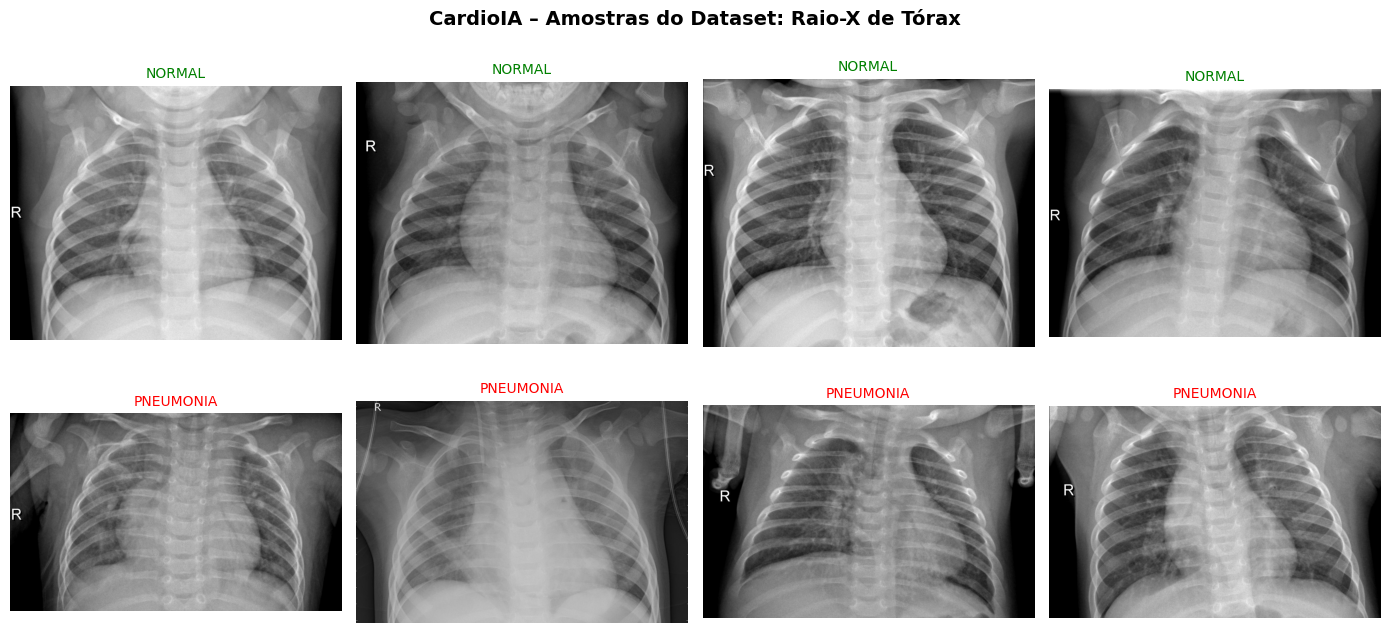

Imagem salva.


In [10]:
# Visualizar amostras do dataset
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('CardioIA – Amostras do Dataset: Raio-X de Tórax',
             fontsize=14, fontweight='bold')

for idx, classe in enumerate(['NORMAL', 'PNEUMONIA']):
    class_path = os.path.join(TRAIN_DIR, classe)
    images     = os.listdir(class_path)[:4]
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)
        axes[idx][j].imshow(img, cmap='gray')
        axes[idx][j].set_title(classe, fontsize=10,
                               color='green' if classe == 'NORMAL' else 'red')
        axes[idx][j].axis('off')

plt.tight_layout()
plt.savefig('/content/amostras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagem salva.")

# Visualizar amostras do dataset
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('CardioIA – Amostras do Dataset: Raio-X de Tórax',
             fontsize=14, fontweight='bold')

for idx, classe in enumerate(['NORMAL', 'PNEUMONIA']):
    class_path = os.path.join(TRAIN_DIR, classe)
    images     = os.listdir(class_path)[:4]
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)
        axes[idx][j].imshow(img, cmap='gray')
        axes[idx][j].set_title(classe, fontsize=10,
                               color='green' if classe == 'NORMAL' else 'red')
        axes[idx][j].axis('off')

plt.tight_layout()
plt.savefig('/content/amostras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagem salva.")

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation apenas no treino
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Calcular class_weight para corrigir desbalanceamento
total = 1341 + 3875
class_weight = {
    0: total / (2 * 1341),  # NORMAL — classe minoritária
    1: total / (2 * 3875)   # PNEUMONIA
}

print(f"Classes: {train_gen.class_indices}")
print(f"Class weights: {class_weight}")
print(f"\nTreino:    {train_gen.samples} imagens")
print(f"Validação: {val_gen.samples} imagens")
print(f"Teste:     {test_gen.samples} imagens")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}

Treino:    5216 imagens
Validação: 16 imagens
Teste:     624 imagens


## Pipeline de Pré-processamento — Resumo

| Etapa | Descrição |
|---|---|
| Redimensionamento | 150x150 pixels |
| Normalização | Pixels divididos por 255 (escala 0-1) |
| Augmentation | Rotação, zoom, flip horizontal |
| Correção de desbalanceamento | class_weight proporcional |
| Split | Treino / Validação / Teste já fornecidos pelo dataset |

In [12]:
# Baixar as imagens geradas para o seu computador
from google.colab import files

files.download('/content/amostras_dataset.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Parte 2A — CNN Simples Treinada do Zero

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer=Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('modelo_cnn_zero.keras', save_best_only=True)
]

history_cnn = model_cnn.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks
)

print("\nTreino concluído.")

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8073 - loss: 0.3897 - val_accuracy: 0.8125 - val_loss: 0.4054
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.9120 - loss: 0.2248 - val_accuracy: 0.6875 - val_loss: 0.8467
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9239 - loss: 0.1961 - val_accuracy: 0.8750 - val_loss: 0.4746
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9325 - loss: 0.1768 - val_accuracy: 0.7500 - val_loss: 0.6383

Treino concluído.


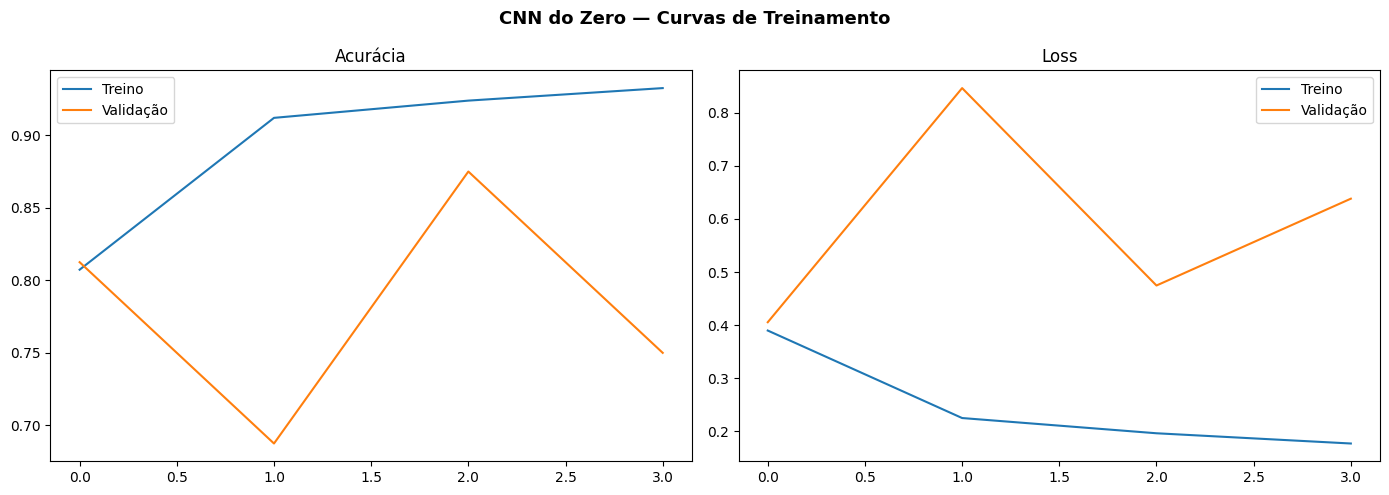

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN do Zero — Curvas de Treinamento', fontsize=13, fontweight='bold')

axes[0].plot(history_cnn.history['accuracy'], label='Treino')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'], label='Treino')
axes[1].plot(history_cnn.history['val_loss'], label='Validação')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/curvas_cnn_zero.png', dpi=150)
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 791ms/step
=== Métricas — CNN do Zero ===

              precision    recall  f1-score   support

      NORMAL       0.91      0.54      0.68       234
   PNEUMONIA       0.78      0.97      0.86       390

    accuracy                           0.81       624
   macro avg       0.84      0.75      0.77       624
weighted avg       0.83      0.81      0.79       624



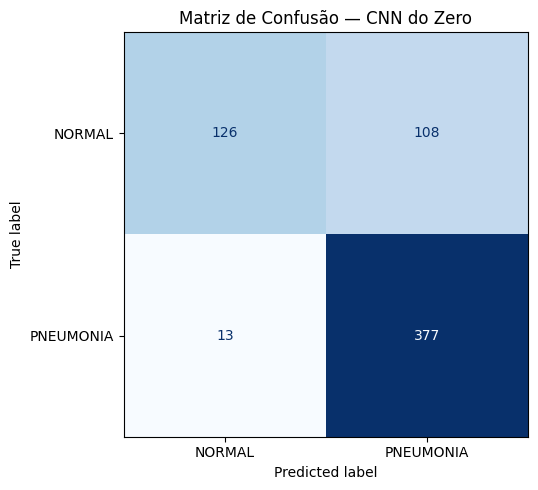

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_gen.reset()
preds = (model_cnn.predict(test_gen) > 0.5).astype(int).flatten()
labels = test_gen.classes

print("=== Métricas — CNN do Zero ===\n")
print(classification_report(labels, preds, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — CNN do Zero')
plt.tight_layout()
plt.savefig('/content/matriz_cnn_zero.png', dpi=150)
plt.show()

## Parte 2B — Transfer Learning com MobileNetV2
MobileNetV2 foi escolhido por ser leve e eficiente para Colab gratuito.

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(input_shape=(150,150,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model_tl = Model(inputs=base_model.input, outputs=output)
model_tl.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])

callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('modelo_mobilenetv2.keras', save_best_only=True)
]

history_tl = model_tl.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks_tl
)

print("Treino concluído.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.8399 - loss: 0.3634 - val_accuracy: 0.8750 - val_loss: 0.3733
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9176 - loss: 0.2123 - val_accuracy: 0.8750 - val_loss: 0.3347
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9252 - loss: 0.1783 - val_accuracy: 0.8750 - val_loss: 0.3636
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9333 - loss: 0.1630 - val_accuracy: 0.8750 - val_loss: 0.2853
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9367 - loss: 0.1578 - val_accuracy: 0.8750 - val_loss: 0.3365
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.9427 - loss: 0.1432 - val_accuracy: 0.8750 - val_loss: 0.2893
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9463 - loss: 0.1392 - val_accuracy: 0.8750 - val_loss: 0.2722
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/

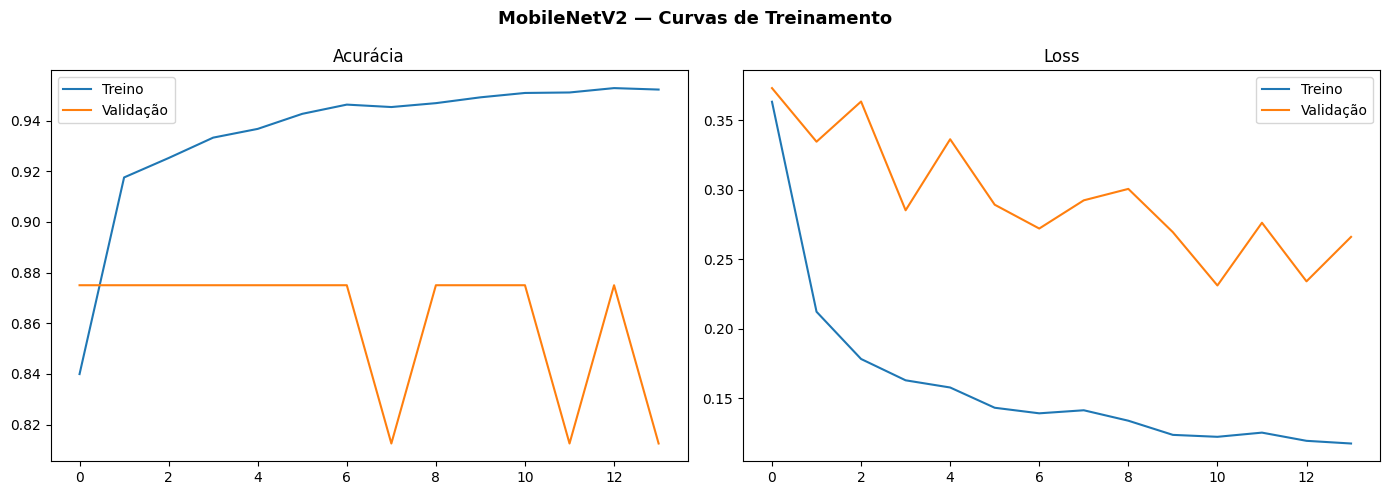

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 840ms/step
=== Métricas — MobileNetV2 ===

              precision    recall  f1-score   support

      NORMAL       0.90      0.81      0.85       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.89       624



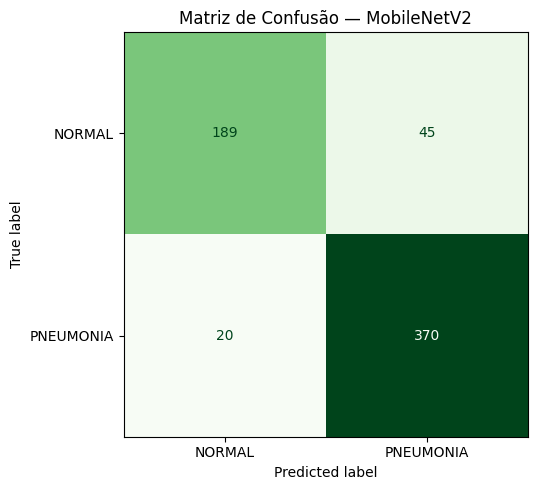

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Curvas de Treinamento', fontsize=13, fontweight='bold')

axes[0].plot(history_tl.history['accuracy'], label='Treino')
axes[0].plot(history_tl.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia')
axes[0].legend()

axes[1].plot(history_tl.history['loss'], label='Treino')
axes[1].plot(history_tl.history['val_loss'], label='Validação')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/curvas_mobilenetv2.png', dpi=150)
plt.show()

# Métricas no teste
test_gen.reset()
preds_tl = (model_tl.predict(test_gen) > 0.5).astype(int).flatten()
labels = test_gen.classes

print("=== Métricas — MobileNetV2 ===\n")
print(classification_report(labels, preds_tl, target_names=['NORMAL', 'PNEUMONIA']))

cm_tl = confusion_matrix(labels, preds_tl)
disp_tl = ConfusionMatrixDisplay(cm_tl, display_labels=['NORMAL', 'PNEUMONIA'])
fig, ax = plt.subplots(figsize=(6,5))
disp_tl.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusão — MobileNetV2')
plt.tight_layout()
plt.savefig('/content/matriz_mobilenetv2.png', dpi=150)
plt.show()

## Protótipo — Classificação Interativa de Raio-X

Envie uma imagem de raio-X de tórax para classificação pelo modelo treinado.

Selecione uma imagem de raio-X de tórax...


Saving person1_virus_6.jpeg to person1_virus_6.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


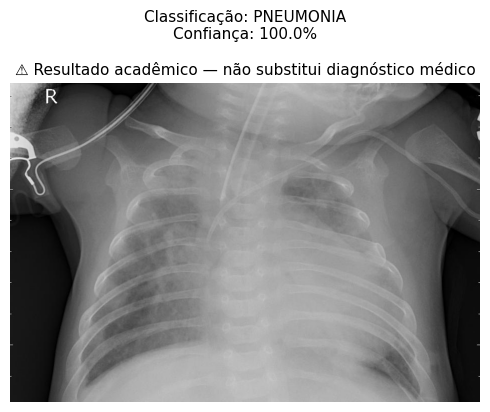

In [20]:
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image

def classificar_imagem():
    print("Selecione uma imagem de raio-X de tórax...")
    uploaded = files.upload()

    for nome in uploaded.keys():
        img = keras_image.load_img(nome, target_size=IMG_SIZE)
        arr = keras_image.img_to_array(img) / 255.0
        arr = np.expand_dims(arr, axis=0)

        prob = model_tl.predict(arr)[0][0]
        classe = 'PNEUMONIA' if prob > 0.5 else 'NORMAL'
        confianca = prob if prob > 0.5 else 1 - prob

        plt.figure(figsize=(5,5))
        plt.imshow(keras_image.load_img(nome))
        plt.axis('off')
        plt.title(
            f"Classificação: {classe}\n"
            f"Confiança: {confianca:.1%}\n\n"
            f"⚠️ Resultado acadêmico — não substitui diagnóstico médico",
            fontsize=11
        )
        plt.tight_layout()
        plt.savefig('/content/predicao_exemplo.png', dpi=150)
        plt.show()

classificar_imagem()

In [21]:
from google.colab import files

files.download('/content/amostras_dataset.png')
files.download('/content/curvas_cnn_zero.png')
files.download('/content/matriz_cnn_zero.png')
files.download('/content/curvas_mobilenetv2.png')
files.download('/content/matriz_mobilenetv2.png')
files.download('/content/predicao_exemplo.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>